#Gerçek Zamanlı Duygu Tanıma — CNN ile FER-2013

Bu projede FER-2013 veri seti kullanılarak CNN tabanlı bir duygu tanıma modeli geliştirilmiştir.
Model 7 farklı duygu sınıfını (angry, disgust, fear, happy, neutral, sad, surprise) tanıyabilmektedir.
Eğitilen model OpenCV ile entegre edilerek gerçek zamanlı webcam üzerinden test edilmiştir.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path = '/content/drive/MyDrive/Colab Notebooks/FER/FER Dataset.zip'
extract_path = '/content/fer_dataset'

print("Zip açılıyor...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Tamamlandı!")

for item in os.listdir(extract_path):
    print(item)

Mounted at /content/drive
Zip açılıyor...
Tamamlandı!
train
test


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


Duygular: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Toplam sınıf: 7
  angry: 3995 görüntü
  disgust: 436 görüntü
  fear: 4097 görüntü
  happy: 7215 görüntü
  neutral: 4965 görüntü
  sad: 4830 görüntü
  surprise: 3171 görüntü


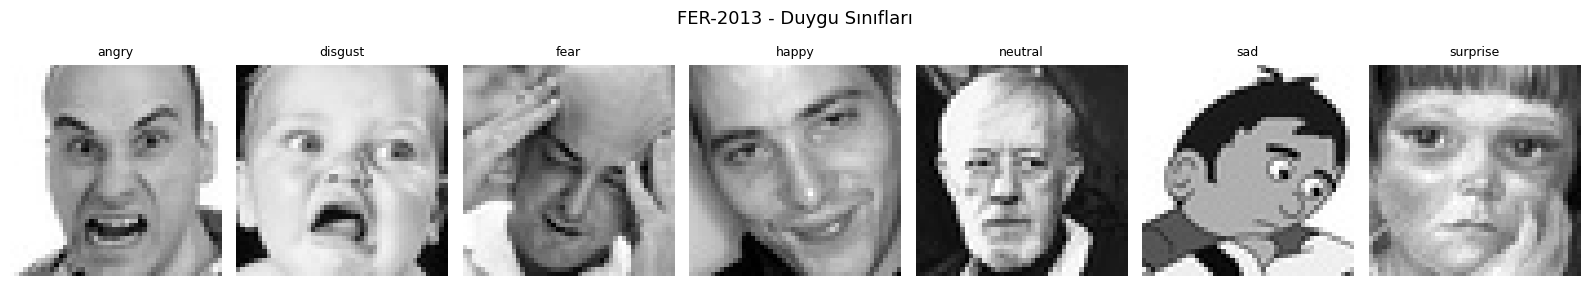

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_path = '/content/fer_dataset/train'
test_path = '/content/fer_dataset/test'

classes = sorted(os.listdir(train_path))
print(f"Duygular: {classes}")
print(f"Toplam sınıf: {len(classes)}")

for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  {cls}: {count} görüntü")

# Örnek görüntüler
fig, axes = plt.subplots(1, len(classes), figsize=(16, 3))
for i, cls in enumerate(classes):
    img_folder = os.path.join(train_path, cls)
    img_file = os.listdir(img_folder)[0]
    #Görüntüyü diskten okur, NumPy dizisine çevirir. 48x48 piksellik görüntü → (48, 48) boyutlu dizi.
    img = mpimg.imread(os.path.join(img_folder, img_file))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis('off')

plt.suptitle('FER-2013 - Duygu Sınıfları', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (48, 48)
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', #etiketleri one-hot encoding'e çevirir.
    color_mode='grayscale',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    subset='validation',
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

print(f"Eğitim: {train_generator.samples} görüntü")
print(f"Validasyon: {val_generator.samples} görüntü")
print(f"Test: {test_generator.samples} görüntü")
print(f"Sınıflar: {train_generator.class_indices}")

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Eğitim: 22968 görüntü
Validasyon: 5741 görüntü
Test: 7178 görüntü
Sınıflar: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # 1. Blok
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # 2. Blok
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # 3. Blok
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,322,855 (5.05 MB)

 Trainable params: 1,321,703 (5.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1)
]

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\nEğitim tamamlandı!")

Epoch 1/30
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2347 - loss: 2.3603
Epoch 1: val_loss improved from None to 2.44480, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 50s 97ms/step - accuracy: 0.2753 - loss: 2.0614 - val_accuracy: 0.2038 - val_loss: 2.4448 - learning_rate: 0.0010
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3622 - loss: 1.6656
Epoch 2: val_loss improved from 2.44480 to 1.63742, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.3836 - loss: 1.6006 - val_accuracy: 0.3701 - val_loss: 1.6374 - learning_rate: 0.0010
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4408 - loss: 1.4494
Epoch 3: val_loss improved from 1.63742 to 1.45637, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - 

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


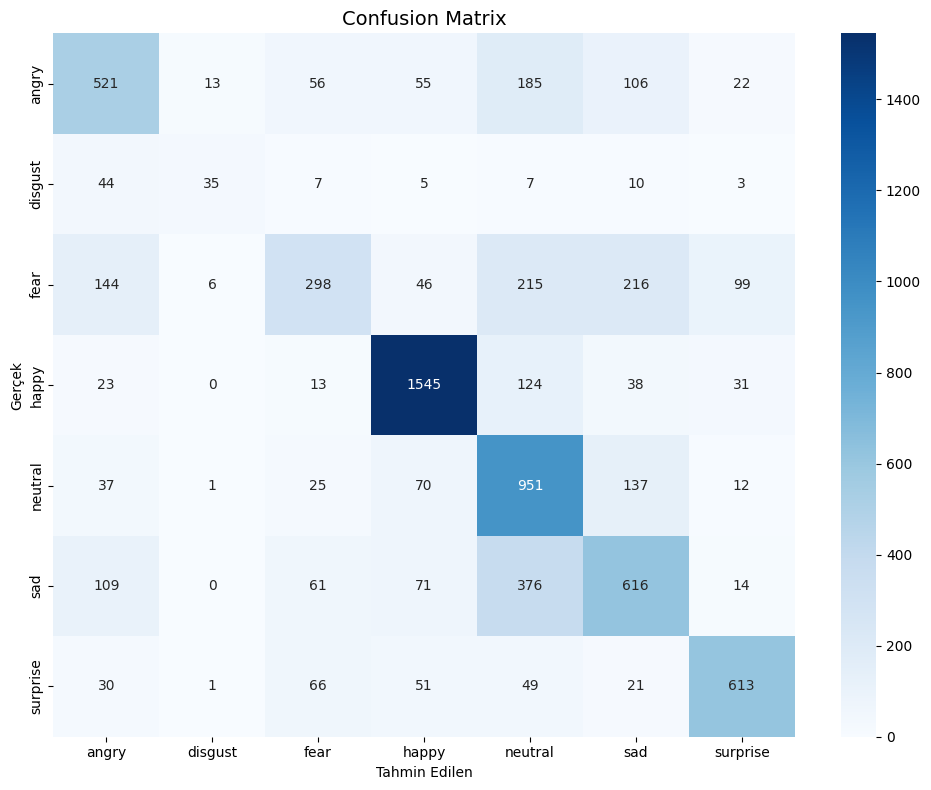


📋 Classification Report:
              precision    recall  f1-score   support

       angry       0.57      0.54      0.56       958
     disgust       0.62      0.32      0.42       111
        fear       0.57      0.29      0.38      1024
       happy       0.84      0.87      0.85      1774
     neutral       0.50      0.77      0.61      1233
         sad       0.54      0.49      0.52      1247
    surprise       0.77      0.74      0.75       831

    accuracy                           0.64      7178
   macro avg       0.63      0.57      0.58      7178
weighted avg       0.64      0.64      0.63      7178



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

#test verisinde değerlendirme
test_generator.reset()

y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [1]:
from IPython.display import display, HTML
#Colab içinde HTML ve JavaScript kodu çalıştırmak için.
#Webcam'i tarayıcıdan açmak için JavaScript lazım, bunu Python'dan HTML olarak gönderiyoruz.

import ipywidgets as widgets
from google.colab import output
import cv2
import numpy as np
import PIL  #JavaScript'ten gelen görüntüyü açmak için
import io   #görüntü verisini bellek üzerinde işlemek için
import base64 #JavaScript görüntüyü metin formatında gönderiyor, base64 bunu tekrar görüntüye çeviriyor

emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
emotion_emojis  = ['😠', '🤢', '😨', '😊', '😐', '😢', '😮']

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def predict_emotion(face_img):
    face = cv2.resize(face_img, (48, 48))
    face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    face = face / 255.0
    face = face.reshape(1, 48, 48, 1)
    pred = model.predict(face, verbose=0)
    idx = np.argmax(pred)
    return emotion_labels[idx], emotion_emojis[idx], pred[0][idx]*100

# Colab'da webcam için güncel yöntem
from google.colab.patches import cv2_imshow

js_code = """
<script>
async function capturePhoto() {
  const video = document.createElement('video');
  const canvas = document.createElement('canvas');
  const stream = await navigator.mediaDevices.getUserMedia({video: true});
  video.srcObject = stream;
  await video.play();
  document.body.appendChild(video);

  await new Promise(r => setTimeout(r, 3000)); // 3 sn bekle

  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);
  stream.getTracks().forEach(t => t.stop());
  video.remove();

  const data = canvas.toDataURL('image/jpeg');
  google.colab.kernel.invokeFunction('notebook.process_image', [data], {});
}
capturePhoto();
</script>
"""

captured_image = None

def process_image(data):
    global captured_image
    img_data = base64.b64decode(data.split(',')[1])
    img = PIL.Image.open(io.BytesIO(img_data))
    captured_image = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    gray = cv2.cvtColor(captured_image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    result = captured_image.copy()
    if len(faces) == 0:
        print("❌ Yüz bulunamadı, tekrar dene!")
    else:
        for (x, y, w, h) in faces:
            face_roi = captured_image[y:y+h, x:x+w]
            emotion, emoji, conf = predict_emotion(face_roi)
            cv2.rectangle(result, (x,y), (x+w,y+h), (0,255,0), 2)
            cv2.putText(result, f"{emotion} {conf:.0f}%", (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)
            print(f"✅ Duygu: {emoji} {emotion} — Güven: {conf:.1f}%")
    cv2_imshow(result)

output.register_callback('notebook.process_image', process_image)
display(HTML(js_code))
print("📸 Kamera açılıyor, 3 saniye içinde poz ver...")

📸 Kamera açılıyor, 3 saniye içinde poz ver...


In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/FER/emotion_model.keras')
print("Model Drive'a kaydedildi!")

Model Drive'a kaydedildi!
